# CNN-BiLSTM Model: AFib vs Normal Sinus Rhythm (12-Lead)

**Dataset:** Chapman-Shaoxing (AFib + Normal Sinus Rhythm subset)  
**Task:** Binary classification — AFib vs Normal  
**Model:** CNN-BiLSTM (adapted from [rajatdagar2005](https://github.com/rajatdagar2005/AFib-Detection-from-ECG-Signals-using-CNN-BiLSTM-MIT-BIH-AFDB-), converted to PyTorch)  
**Input:** 12-lead ECG, 500 Hz, 10-second recordings (no windowing)  
**Setup:** 5-fold stratified CV by patient IDs (same split as KanResWideX, seed=42)

### Architecture:
- CNN Block 1: Conv1D(64, k=7) → BN → MaxPool(3) → Dropout(0.2)
- CNN Block 2: Conv1D(128, k=5) → BN → MaxPool(2) → Dropout(0.2)
- CNN Block 3: Conv1D(256, k=3) → BN → MaxPool(2) → Dropout(0.3)
- BiLSTM 1: Bidirectional LSTM(128) → Dropout(0.3)
- BiLSTM 2: Bidirectional LSTM(64) → Dropout(0.3)
- Dense(128) → BN → Dropout(0.4)
- Dense(64) → Dropout(0.3)
- Output(2, softmax)


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

!pip install wfdb -q
print('Drive mounted and dependencies installed.')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 113.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
Drive mounted and dependencies installed.


## 1. Imports

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, matthews_corrcoef,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import wfdb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Configuration

In [3]:
class Config:
    afib_dir = ""
    normal_dir = ""

    fs = 500
    num_channels = 12
    recording_seconds = 10
    recording_samples = fs * recording_seconds  # 5000

    num_classes = 2
    batch_size = 64
    num_epochs = 50
    learning_rate = 1e-3
    weight_decay = 1e-4
    early_stop_patience = 10
    n_folds = 5
    random_seed = 42

    pdf_dir = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/plots_pdf_cnn_bilstm"
    model_save_dir = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model"

config = Config()
os.makedirs(config.pdf_dir, exist_ok=True)
os.makedirs(config.model_save_dir, exist_ok=True)
print("Config ready.")

Config ready.


## 3. Unzip Data to Local Disk

In [4]:
import os

if not os.path.exists("/content/subset_data"):
    print("Unzipping subset to local disk...")
    !unzip -q "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/afib_normal_subset_ecg_arrhythmia.zip" -d /content/subset_data/
    print("Unzip complete!")

# Auto-detect folder structure
for base in ["/content/subset_data",
             "/content/subset_data/afib_normal_subset",
             "/content/subset_data/afib_normal_subset_ecg_arrhythmia"]:
    afib_path = os.path.join(base, "afib")
    normal_path = os.path.join(base, "normal")
    if os.path.exists(afib_path) and os.path.exists(normal_path):
        config.afib_dir = afib_path
        config.normal_dir = normal_path
        break

print(f"AFib records: {len([f for f in os.listdir(config.afib_dir) if f.endswith('.hea')])}")
print(f"Normal records: {len([f for f in os.listdir(config.normal_dir) if f.endswith('.hea')])}")
print("Using local disk.")

Unzipping subset to local disk...
Unzip complete!
AFib records: 1780
Normal records: 8125
Using local disk.


## 4. Model Definition: CNN-BiLSTM

Architecture adapted from [rajatdagar2005/AFib-Detection-from-ECG-Signals-using-CNN-BiLSTM](https://github.com/rajatdagar2005/AFib-Detection-from-ECG-Signals-using-CNN-BiLSTM-MIT-BIH-AFDB-), converted from Keras to PyTorch and adapted for 12-lead input.

In [5]:
class CNNBiLSTM(nn.Module):
    """
    CNN-BiLSTM hybrid model for AFib detection.
    CNN blocks extract local ECG features, BiLSTM captures temporal dependencies.
    Adapted from rajatdagar2005 (Keras) to PyTorch, modified for 12-lead input.
    """
    def __init__(self, input_channels=12, output_size=2):
        super().__init__()

        # CNN Block 1 - Extract local features
        self.cnn1 = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3),
            nn.Dropout(0.2)
        )

        # CNN Block 2
        self.cnn2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )

        # CNN Block 3
        self.cnn3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3)
        )

        # BiLSTM Block 1 - Capture temporal dependencies
        self.bilstm1 = nn.LSTM(
            input_size=256, hidden_size=128,
            batch_first=True, bidirectional=True
        )
        self.dropout_lstm1 = nn.Dropout(0.3)

        # BiLSTM Block 2
        self.bilstm2 = nn.LSTM(
            input_size=256, hidden_size=64,
            batch_first=True, bidirectional=True
        )
        self.dropout_lstm2 = nn.Dropout(0.3)

        # Dense layers for classification
        self.classifier = nn.Sequential(
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        # x shape: (batch, channels, time) = (batch, 12, 5000)

        # CNN feature extraction
        x = self.cnn1(x)   # (batch, 64, 1666)
        x = self.cnn2(x)   # (batch, 128, 833)
        x = self.cnn3(x)   # (batch, 256, 416)

        # Transpose for LSTM: (batch, time, features)
        x = x.permute(0, 2, 1)  # (batch, 416, 256)

        # BiLSTM layers
        x, _ = self.bilstm1(x)      # (batch, 416, 256)
        x = self.dropout_lstm1(x)
        x, _ = self.bilstm2(x)      # (batch, 416, 128)
        x = self.dropout_lstm2(x)

        # Take the last time step output
        x = x[:, -1, :]             # (batch, 128)

        # Classification
        x = self.classifier(x)      # (batch, 2)
        return x

model = CNNBiLSTM(input_channels=12, output_size=2)
total_params = sum(p.numel() for p in model.parameters())
print(f"CNN-BiLSTM model defined (12-channel input).")
print(f"Total parameters: {total_params:,}")

CNN-BiLSTM model defined (12-channel input).
Total parameters: 731,266


## 5. Discover Records

In [6]:
afib_files = sorted([f[:-4] for f in os.listdir(config.afib_dir) if f.endswith('.hea')])
normal_files = sorted([f[:-4] for f in os.listdir(config.normal_dir) if f.endswith('.hea')])

all_records = []
for name in afib_files:
    all_records.append({"path": os.path.join(config.afib_dir, name), "name": name, "label": 1})
for name in normal_files:
    all_records.append({"path": os.path.join(config.normal_dir, name), "name": name, "label": 0})

print(f"AFib records:   {len(afib_files)}")
print(f"Normal records: {len(normal_files)}")
print(f"Total subset:   {len(all_records)}")
print(f"AFib prevalence: {len(afib_files)/len(all_records):.2%}")

AFib records:   1780
Normal records: 8125
Total subset:   9905
AFib prevalence: 17.97%


## 6. Load and Preprocess (Full 10s, No Windowing)

In [7]:
def load_record(record_info, config):
    try:
        rec = wfdb.rdrecord(record_info["path"])
        signal = rec.p_signal
    except Exception as e:
        return None, None

    if signal.shape[1] < config.num_channels:
        return None, None

    if np.any(np.isnan(signal)):
        return None, None

    if len(signal) < config.recording_samples:
        pad = np.zeros((config.recording_samples - len(signal), config.num_channels))
        signal = np.vstack([signal, pad])
    elif len(signal) > config.recording_samples:
        signal = signal[:config.recording_samples, :]

    for ch in range(config.num_channels):
        std = np.std(signal[:, ch])
        if std < 1e-6:
            signal[:, ch] = np.random.normal(0, 1e-4, len(signal[:, ch]))
        else:
            signal[:, ch] = (signal[:, ch] - np.mean(signal[:, ch])) / std

    sample = signal[:, :config.num_channels].T.copy().astype(np.float32)
    label = np.int64(record_info["label"])
    return sample, label

s, l = load_record(all_records[0], config)
if s is not None:
    print(f"Test: {all_records[0]['name']} -> shape {s.shape}, label={l}")
    print(f"  {s.shape[0]} channels x {s.shape[1]} samples ({config.recording_seconds}s at {config.fs} Hz)")

Test: JS00001 -> shape (12, 5000), label=1
  12 channels x 5000 samples (10s at 500 Hz)


## 7. Load All Records

In [8]:
print(f"Loading {len(all_records)} records...")
start_time = time.time()

patient_data = {}
skipped = 0

for i, rec in enumerate(all_records):
    if (i + 1) % 2000 == 0:
        elapsed = time.time() - start_time
        print(f"  Processed {i+1}/{len(all_records)} ({elapsed:.0f}s)...")

    sample, label = load_record(rec, config)
    if sample is not None:
        patient_data[rec["name"]] = {"sample": sample, "label": label}
    else:
        skipped += 1

load_time = time.time() - start_time
print(f"\nLoading complete in {load_time/60:.1f} minutes")
print(f"Patients loaded: {len(patient_data)} (skipped: {skipped})")

afib_patients = sum(1 for p in patient_data.values() if p["label"] == 1)
normal_patients = sum(1 for p in patient_data.values() if p["label"] == 0)
print(f"  AFib patients:   {afib_patients}")
print(f"  Normal patients: {normal_patients}")
print(f"  Total samples:   {len(patient_data)} (1 per patient)")

Loading 9905 records...
  Processed 2000/9905 (20s)...
  Processed 4000/9905 (40s)...
  Processed 6000/9905 (60s)...
  Processed 8000/9905 (80s)...

Loading complete in 1.7 minutes
Patients loaded: 9889 (skipped: 16)
  AFib patients:   1780
  Normal patients: 8109
  Total samples:   9889 (1 per patient)


## 8. 5-Fold Stratified Split (Same seed=42 as KanResWideX)

In [9]:
np.random.seed(config.random_seed)

patient_names = np.array(sorted(patient_data.keys()))
patient_labels = np.array([patient_data[p]["label"] for p in patient_names])

skf = StratifiedKFold(n_splits=config.n_folds, shuffle=True, random_state=config.random_seed)

folds = []
print("=" * 90)
print("5-FOLD STRATIFIED SPLIT BY PATIENT IDs (same seed=42 as KanResWideX)")
print("=" * 90)
print(f"\n{'Fold':<6} {'Train Pts':<12} {'Val Pts':<10} {'Train AFib':<13} {'Train Normal':<14} {'Val AFib':<11} {'Val Normal':<12} {'Val AFib %':<10}")
print("-" * 90)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(patient_names, patient_labels)):
    train_patients = patient_names[train_idx].tolist()
    val_patients = patient_names[val_idx].tolist()
    train_afib = sum(1 for p in train_patients if patient_data[p]["label"] == 1)
    train_normal = sum(1 for p in train_patients if patient_data[p]["label"] == 0)
    val_afib = sum(1 for p in val_patients if patient_data[p]["label"] == 1)
    val_normal = sum(1 for p in val_patients if patient_data[p]["label"] == 0)
    folds.append({"train": train_patients, "val": val_patients})
    val_afib_pct = val_afib / (val_afib + val_normal) * 100
    print(f"{fold_idx+1:<6} {len(train_patients):<12} {len(val_patients):<10} {train_afib:<13} {train_normal:<14} {val_afib:<11} {val_normal:<12} {val_afib_pct:<.1f}%")

print("-" * 90)
print(f"\nTotal patients: {len(patient_names)} (AFib: {sum(patient_labels)}, Normal: {len(patient_labels) - sum(patient_labels)})")

5-FOLD STRATIFIED SPLIT BY PATIENT IDs (same seed=42 as KanResWideX)

Fold   Train Pts    Val Pts    Train AFib    Train Normal   Val AFib    Val Normal   Val AFib %
------------------------------------------------------------------------------------------
1      7911         1978       1424          6487           356         1622         18.0%
2      7911         1978       1424          6487           356         1622         18.0%
3      7911         1978       1424          6487           356         1622         18.0%
4      7911         1978       1424          6487           356         1622         18.0%
5      7912         1977       1424          6488           356         1621         18.0%
------------------------------------------------------------------------------------------

Total patients: 9889 (AFib: 1780, Normal: 8109)


## 9. Helper Functions

In [10]:
class ECGDataset(Dataset):
    def __init__(self, samples, labels):
        self.samples = torch.FloatTensor(samples)
        self.labels = torch.LongTensor(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.samples[idx], self.labels[idx]

def merge_patients(patient_list):
    s_list, l_list = [], []
    for p in patient_list:
        s_list.append(patient_data[p]["sample"])
        l_list.append(patient_data[p]["label"])
    return np.array(s_list, dtype=np.float32), np.array(l_list, dtype=np.int64)

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return running_loss / total, correct / total

def evaluate_full(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets, all_probs = [], [], []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            probs = torch.softmax(outputs, dim=1)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    total = len(all_targets)
    return running_loss / total, np.array(all_targets), np.array(all_preds), np.array(all_probs)

def compute_all_metrics(targets, preds, probs):
    cm = confusion_matrix(targets, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(targets, preds)
    prec = precision_score(targets, preds, pos_label=1, zero_division=0)
    rec = recall_score(targets, preds, pos_label=1, zero_division=0)
    f1 = f1_score(targets, preds, pos_label=1, zero_division=0)
    mcc = matthews_corrcoef(targets, preds)
    auroc = roc_auc_score(targets, probs)
    auprc = average_precision_score(targets, probs)
    brier = brier_score_loss(targets, probs)
    n_bins = 10
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece, mce = 0.0, 0.0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (probs >= bin_boundaries[i]) & (probs < bin_boundaries[i + 1])
        else:
            mask = (probs >= bin_boundaries[i]) & (probs <= bin_boundaries[i + 1])
        bin_count = mask.sum()
        if bin_count > 0:
            bin_acc = targets[mask].mean()
            bin_conf = probs[mask].mean()
            cal_error = abs(bin_acc - bin_conf)
            ece += (bin_count / len(targets)) * cal_error
            mce = max(mce, cal_error)
    metrics = {"tn": tn, "fp": fp, "fn": fn, "tp": tp, "accuracy": acc, "precision": prec,
               "recall": rec, "f1": f1, "mcc": mcc, "auroc": auroc, "auprc": auprc,
               "brier": brier, "ece": ece, "mce": mce, "cm": cm}
    return metrics

print("All functions defined.")

All functions defined.


## 10. Run 5-Fold Cross-Validation (CNN-BiLSTM)

In [11]:
all_fold_metrics = []
all_fold_targets = []
all_fold_preds = []
all_fold_probs = []
all_fold_histories = []
all_fold_model_states = []

total_cv_start = time.time()

for fold_idx, fold in enumerate(folds):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx+1}/{config.n_folds}")
    print(f"{'='*70}")

    X_train, y_train = merge_patients(fold["train"])
    X_val, y_val = merge_patients(fold["val"])
    print(f"  Train: {len(y_train):,} (AFib: {np.sum(y_train==1):,}, Normal: {np.sum(y_train==0):,})")
    print(f"  Val:   {len(y_val):,} (AFib: {np.sum(y_val==1):,}, Normal: {np.sum(y_val==0):,})")

    train_loader = DataLoader(ECGDataset(X_train, y_train), batch_size=config.batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(ECGDataset(X_val, y_val), batch_size=config.batch_size, shuffle=False, num_workers=2, pin_memory=True)

    model = CNNBiLSTM(input_channels=config.num_channels, output_size=config.num_classes).to(device)

    class_counts = Counter(y_train.tolist())
    class_weights = torch.FloatTensor([len(y_train) / (config.num_classes * class_counts[i]) for i in range(config.num_classes)]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    best_val_loss = float("inf")
    best_model_state = None
    patience_counter = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": []}

    print(f"  {'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Time':<8}")
    print(f"  {'-'*52}")

    fold_start = time.time()
    for epoch in range(1, config.num_epochs + 1):
        epoch_start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, _, _, _ = evaluate_full(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        epoch_time = time.time() - epoch_start
        note = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            note = " *"
        else:
            patience_counter += 1
        print(f"  {epoch:<8} {train_loss:<12.4f} {train_acc:<12.4f} {val_loss:<12.4f} {epoch_time:<.0f}s{note}")
        if patience_counter >= config.early_stop_patience:
            print(f"  Early stopping at epoch {epoch}")
            break

    fold_time = time.time() - fold_start
    model.load_state_dict(best_model_state)
    _, targets, preds, probs = evaluate_full(model, val_loader, criterion, device)
    metrics = compute_all_metrics(targets, preds, probs)

    all_fold_metrics.append(metrics)
    all_fold_targets.append(targets)
    all_fold_preds.append(preds)
    all_fold_probs.append(probs)
    all_fold_histories.append(history)
    all_fold_model_states.append(best_model_state)

    print(f"\n  Fold {fold_idx+1} ({fold_time/60:.1f} min): Acc={metrics['accuracy']:.4f} F1={metrics['f1']:.4f} MCC={metrics['mcc']:.4f} AUROC={metrics['auroc']:.4f}")
    print(f"  TN={metrics['tn']} FP={metrics['fp']} FN={metrics['fn']} TP={metrics['tp']}")
    print(f"  Brier={metrics['brier']:.4f} ECE={metrics['ece']:.4f} MCE={metrics['mce']:.4f}")

total_cv_time = time.time() - total_cv_start
print(f"\n\nTotal CV time: {total_cv_time/60:.1f} minutes")


FOLD 1/5
  Train: 7,911 (AFib: 1,424, Normal: 6,487)
  Val:   1,978 (AFib: 356, Normal: 1,622)
  Epoch    Train Loss   Train Acc    Val Loss     Time    
  ----------------------------------------------------
  1        0.6413       0.6591       0.5938       4s *
  2        0.5299       0.7718       0.5401       3s *
  3        0.4688       0.7875       0.3951       3s *
  4        0.3840       0.8366       0.4692       3s
  5        0.2908       0.8841       0.1605       3s *
  6        0.2946       0.8889       0.1079       3s *
  7        0.1704       0.9340       0.0729       3s *
  8        0.0933       0.9689       0.0721       3s *
  9        0.0752       0.9742       0.0593       3s *
  10       0.1155       0.9604       0.0607       3s
  11       0.1099       0.9621       0.0689       3s
  12       0.0602       0.9812       0.0606       3s
  13       0.0771       0.9704       0.0611       3s
  14       0.0552       0.9803       0.0605       3s
  15       0.0935       0.9583  

## 11. Cross-Validation Summary Table

In [12]:
metric_names = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier", "ece", "mce", "tn", "fp", "fn", "tp"]

print("=" * 120)
print("5-FOLD CROSS-VALIDATION RESULTS (CNN-BiLSTM, 12-Lead, AFib vs Normal)")
print("=" * 120)
header = f"{'Metric':<12}"
for i in range(len(folds)):
    header += f"{'Fold '+str(i+1):<14}"
header += f"{'Mean':<14}{'Std':<14}"
print(header)
print("-" * 120)

for metric in metric_names:
    values = [m[metric] for m in all_fold_metrics]
    row = f"{metric.upper():<12}"
    for v in values:
        if metric in ["tn", "fp", "fn", "tp"]:
            row += f"{int(v):<14}"
        else:
            row += f"{v:<14.4f}"
    mean_v, std_v = np.mean(values), np.std(values)
    if metric in ["tn", "fp", "fn", "tp"]:
        row += f"{mean_v:<14.0f}{std_v:<14.0f}"
    else:
        row += f"{mean_v:<14.4f}{std_v:<14.4f}"
    print(row)
print("=" * 120)

5-FOLD CROSS-VALIDATION RESULTS (CNN-BiLSTM, 12-Lead, AFib vs Normal)
Metric      Fold 1        Fold 2        Fold 3        Fold 4        Fold 5        Mean          Std           
------------------------------------------------------------------------------------------------------------------------
ACCURACY    0.9904        0.9884        0.9884        0.9944        0.9899        0.9903        0.0022        
PRECISION   0.9616        0.9440        0.9512        0.9726        0.9590        0.9577        0.0097        
RECALL      0.9860        0.9944        0.9860        0.9972        0.9860        0.9899        0.0049        
F1          0.9736        0.9685        0.9683        0.9847        0.9723        0.9735        0.0060        
MCC         0.9679        0.9619        0.9614        0.9815        0.9663        0.9678        0.0073        
AUROC       0.9976        0.9976        0.9978        0.9991        0.9993        0.9983        0.0008        
AUPRC       0.9881        0.9804

## 12. Confusion Matrices

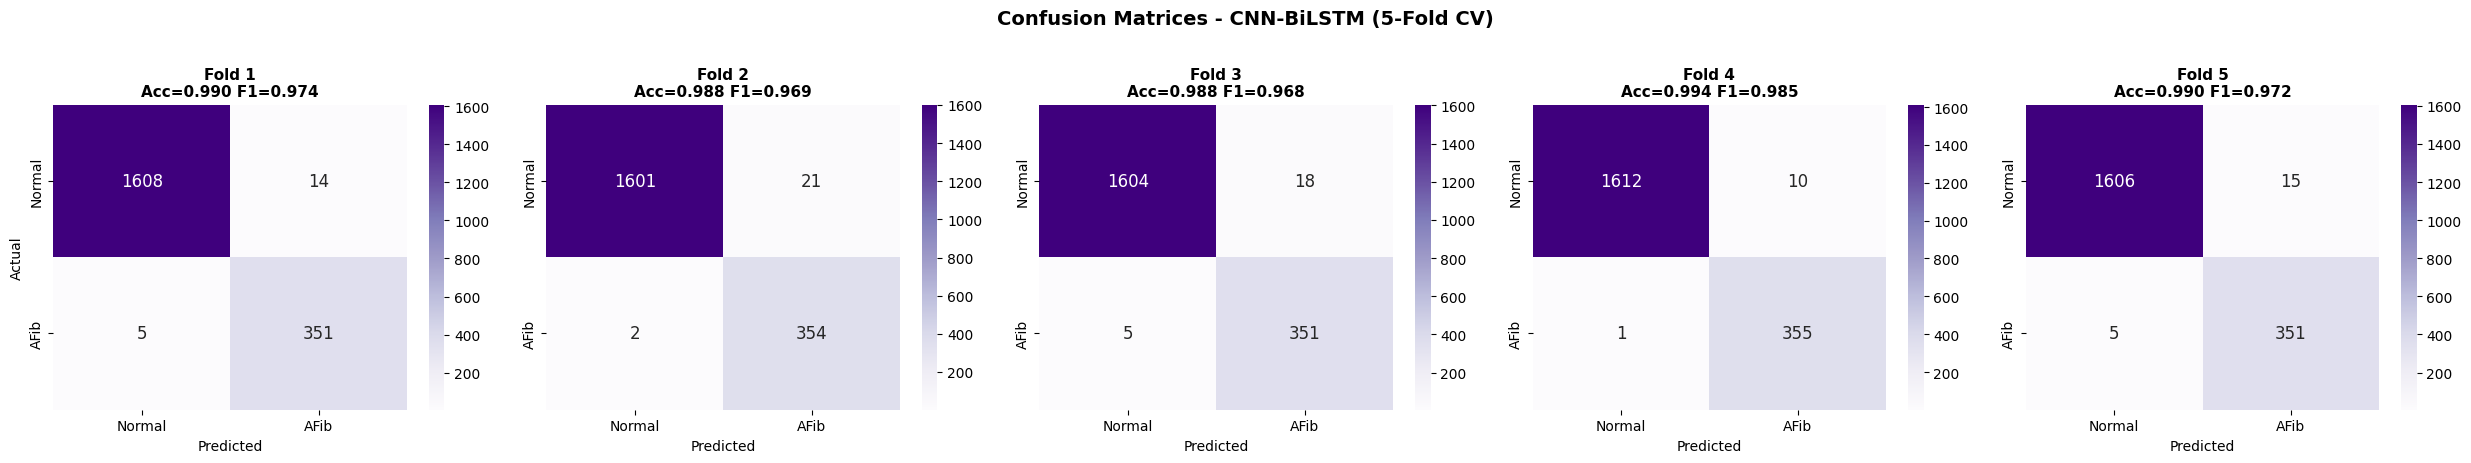

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4.5))
for i, metrics in enumerate(all_fold_metrics):
    ax = axes[i]
    sns.heatmap(metrics["cm"], annot=True, fmt="d", cmap="Purples",
                xticklabels=["Normal", "AFib"], yticklabels=["Normal", "AFib"],
                ax=ax, annot_kws={"size": 12})
    ax.set_title(f"Fold {i+1}\nAcc={metrics['accuracy']:.3f} F1={metrics['f1']:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if i == 0 else "")

plt.suptitle("Confusion Matrices - CNN-BiLSTM (5-Fold CV)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "cnn_bilstm_confusion_matrices.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 13. ROC Curves

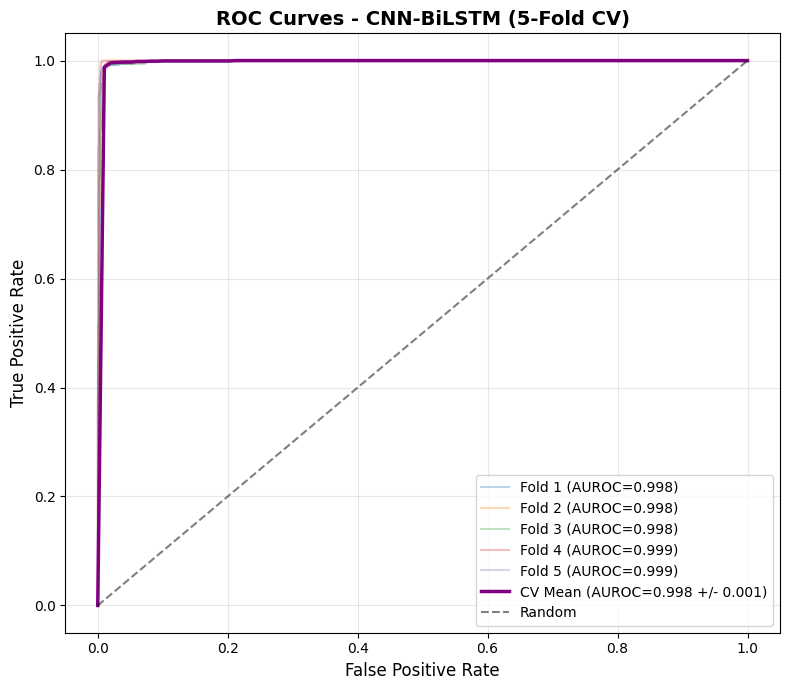

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))
mean_fpr = np.linspace(0, 1, 100)
tprs = []
for i in range(len(folds)):
    fpr, tpr, _ = roc_curve(all_fold_targets[i], all_fold_probs[i])
    ax.plot(fpr, tpr, alpha=0.3, linewidth=1.5, label=f'Fold {i+1} (AUROC={all_fold_metrics[i]["auroc"]:.3f})')
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auroc = np.mean([m["auroc"] for m in all_fold_metrics])
std_auroc = np.std([m["auroc"] for m in all_fold_metrics])
ax.plot(mean_fpr, mean_tpr, color='purple', linewidth=2.5, label=f'CV Mean (AUROC={mean_auroc:.3f} +/- {std_auroc:.3f})')
std_tpr = np.std(tprs, axis=0)
ax.fill_between(mean_fpr, np.maximum(mean_tpr - std_tpr, 0), np.minimum(mean_tpr + std_tpr, 1), color='purple', alpha=0.1)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - CNN-BiLSTM (5-Fold CV)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "cnn_bilstm_roc_curves.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 14. Precision-Recall Curves

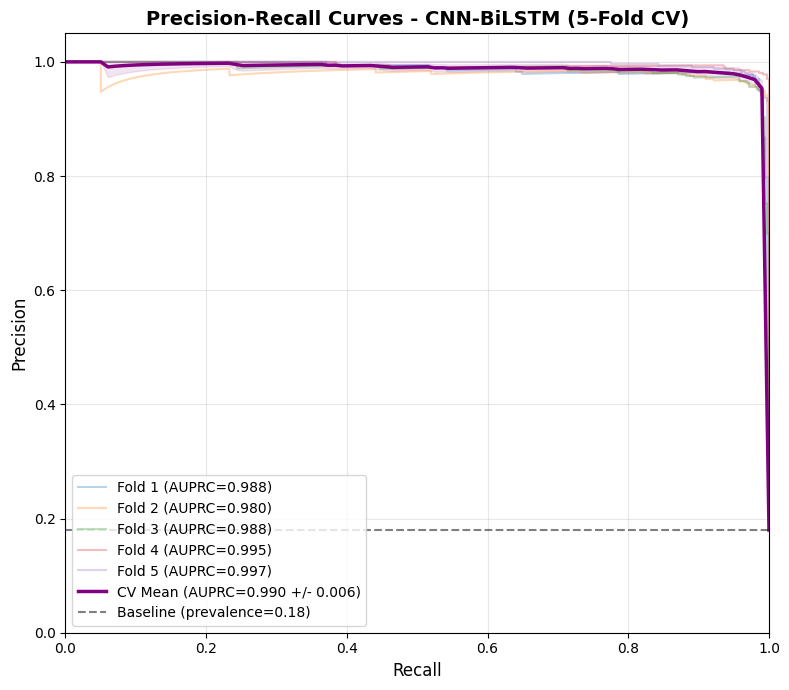

In [15]:
fig, ax = plt.subplots(figsize=(8, 7))
mean_recall_pts = np.linspace(0, 1, 100)
precisions_interp = []
for i in range(len(folds)):
    prec_c, rec_c, _ = precision_recall_curve(all_fold_targets[i], all_fold_probs[i])
    ax.plot(rec_c, prec_c, alpha=0.3, linewidth=1.5, label=f'Fold {i+1} (AUPRC={all_fold_metrics[i]["auprc"]:.3f})')
    prec_interp = np.interp(mean_recall_pts, rec_c[::-1], prec_c[::-1])
    precisions_interp.append(prec_interp)
mean_prec = np.mean(precisions_interp, axis=0)
mean_auprc = np.mean([m["auprc"] for m in all_fold_metrics])
std_auprc = np.std([m["auprc"] for m in all_fold_metrics])
ax.plot(mean_recall_pts, mean_prec, color='purple', linewidth=2.5, label=f'CV Mean (AUPRC={mean_auprc:.3f} +/- {std_auprc:.3f})')
std_prec = np.std(precisions_interp, axis=0)
ax.fill_between(mean_recall_pts, np.maximum(mean_prec - std_prec, 0), np.minimum(mean_prec + std_prec, 1), color='purple', alpha=0.1)
all_targets_combined = np.concatenate(all_fold_targets)
baseline = np.mean(all_targets_combined)
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.5, label=f'Baseline (prevalence={baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - CNN-BiLSTM (5-Fold CV)', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "cnn_bilstm_precision_recall_curves.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 15. Calibration Plots (Reliability Diagrams)

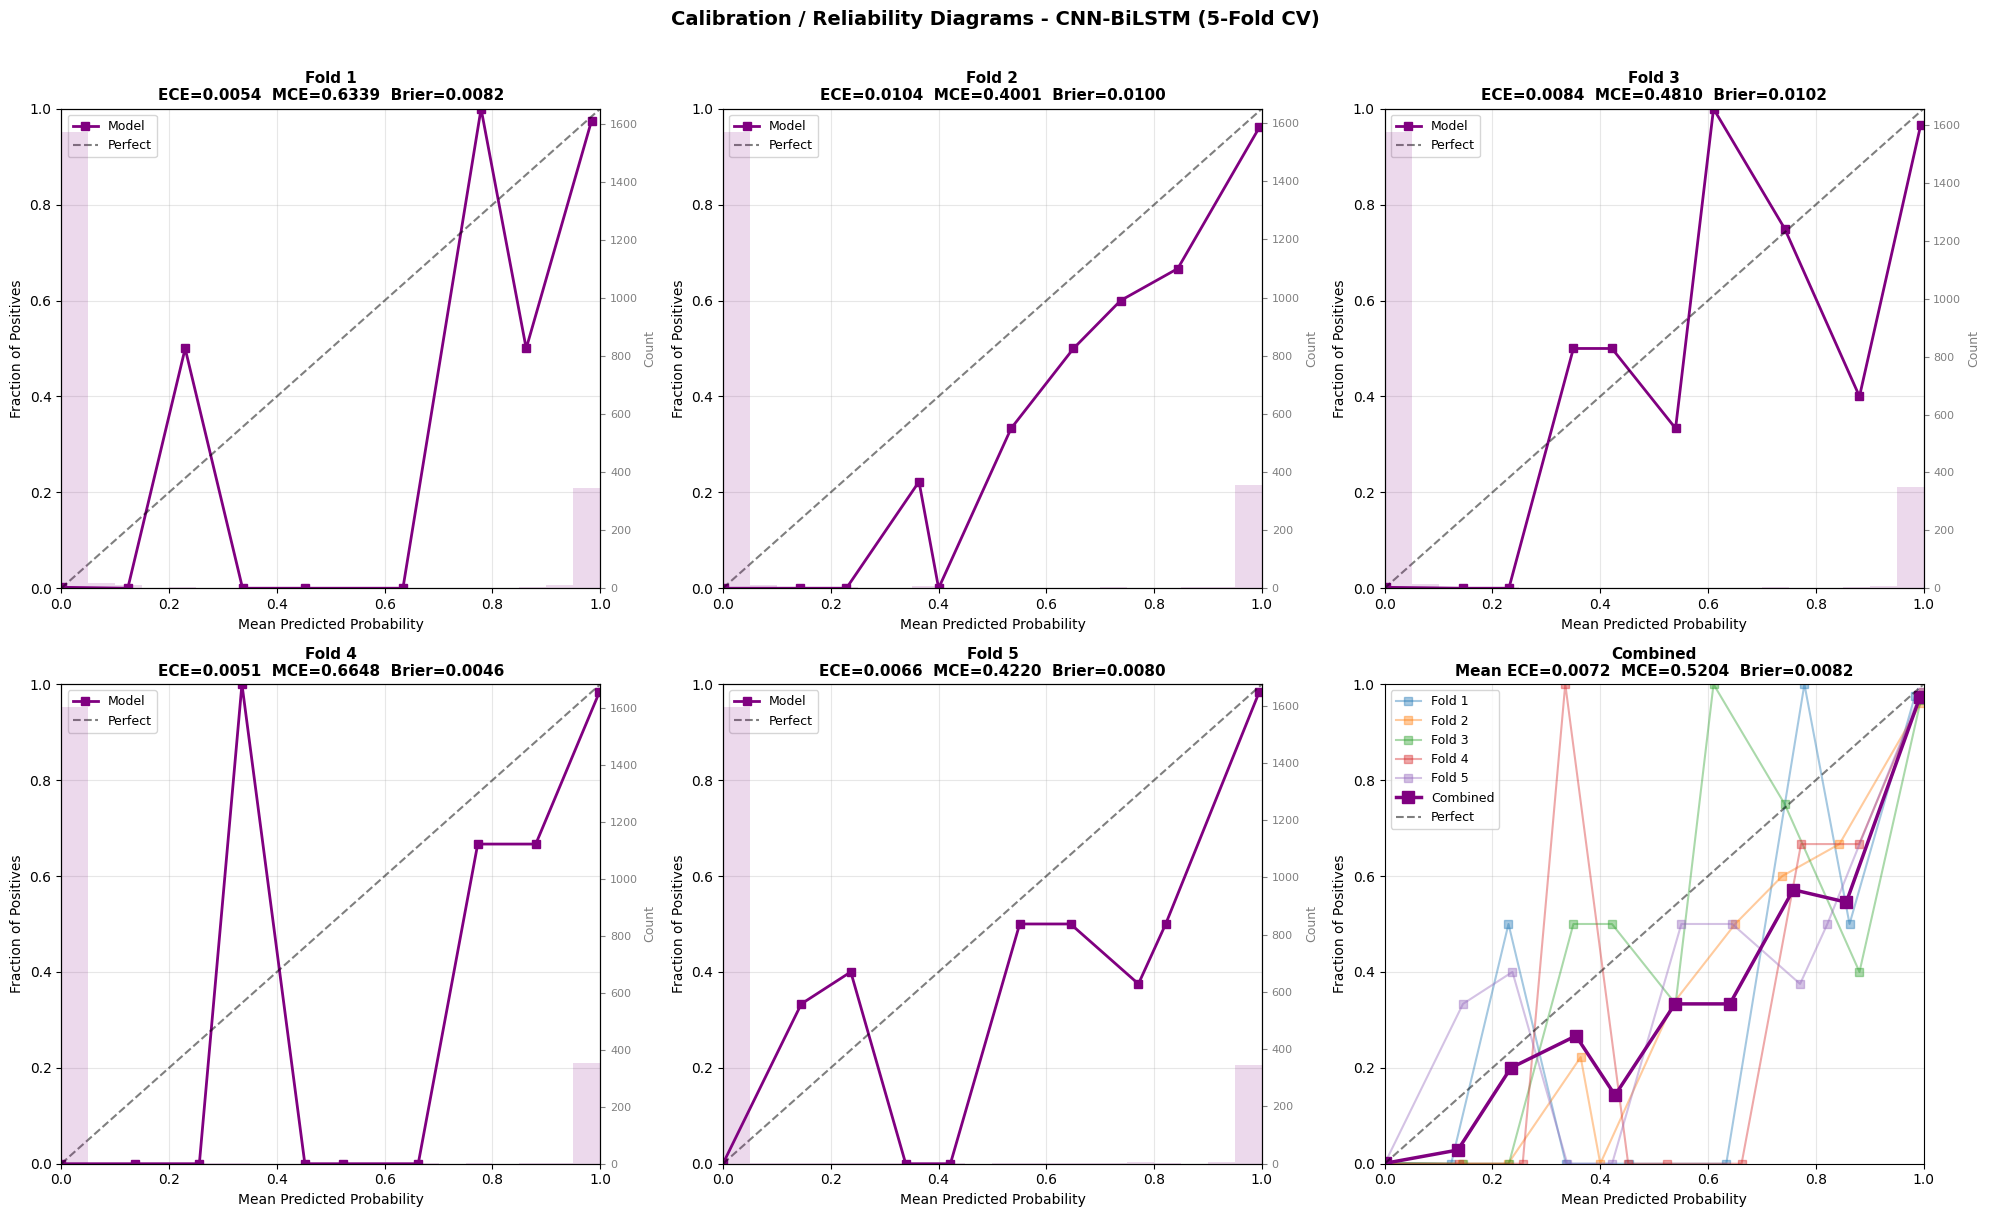

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for i in range(len(folds)):
    row, col = i // 3, i % 3
    ax = axes[row][col]
    fraction_pos, mean_predicted = calibration_curve(all_fold_targets[i], all_fold_probs[i], n_bins=10, strategy='uniform')
    ax.plot(mean_predicted, fraction_pos, 's-', color='purple', linewidth=2, markersize=6, label='Model')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax2 = ax.twinx()
    ax2.hist(all_fold_probs[i], bins=20, range=(0, 1), alpha=0.15, color='purple')
    ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
    ax2.tick_params(axis='y', labelsize=8, colors='gray')
    m = all_fold_metrics[i]
    ax.set_title(f"Fold {i+1}\nECE={m['ece']:.4f}  MCE={m['mce']:.4f}  Brier={m['brier']:.4f}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

ax = axes[1][2]
for i in range(len(folds)):
    fraction_pos, mean_predicted = calibration_curve(all_fold_targets[i], all_fold_probs[i], n_bins=10, strategy='uniform')
    ax.plot(mean_predicted, fraction_pos, 's-', alpha=0.4, linewidth=1.5, label=f'Fold {i+1}')
all_t = np.concatenate(all_fold_targets)
all_p = np.concatenate(all_fold_probs)
frac_all, mean_all = calibration_curve(all_t, all_p, n_bins=10, strategy='uniform')
ax.plot(mean_all, frac_all, 's-', color='purple', linewidth=2.5, markersize=8, label='Combined')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
mean_ece = np.mean([m['ece'] for m in all_fold_metrics])
mean_mce = np.mean([m['mce'] for m in all_fold_metrics])
mean_brier = np.mean([m['brier'] for m in all_fold_metrics])
ax.set_title(f"Combined\nMean ECE={mean_ece:.4f}  MCE={mean_mce:.4f}  Brier={mean_brier:.4f}", fontsize=11, fontweight='bold')
ax.set_xlabel('Mean Predicted Probability'); ax.set_ylabel('Fraction of Positives')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.suptitle("Calibration / Reliability Diagrams - CNN-BiLSTM (5-Fold CV)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "cnn_bilstm_calibration_plots.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 16. Predicted Probability Distributions

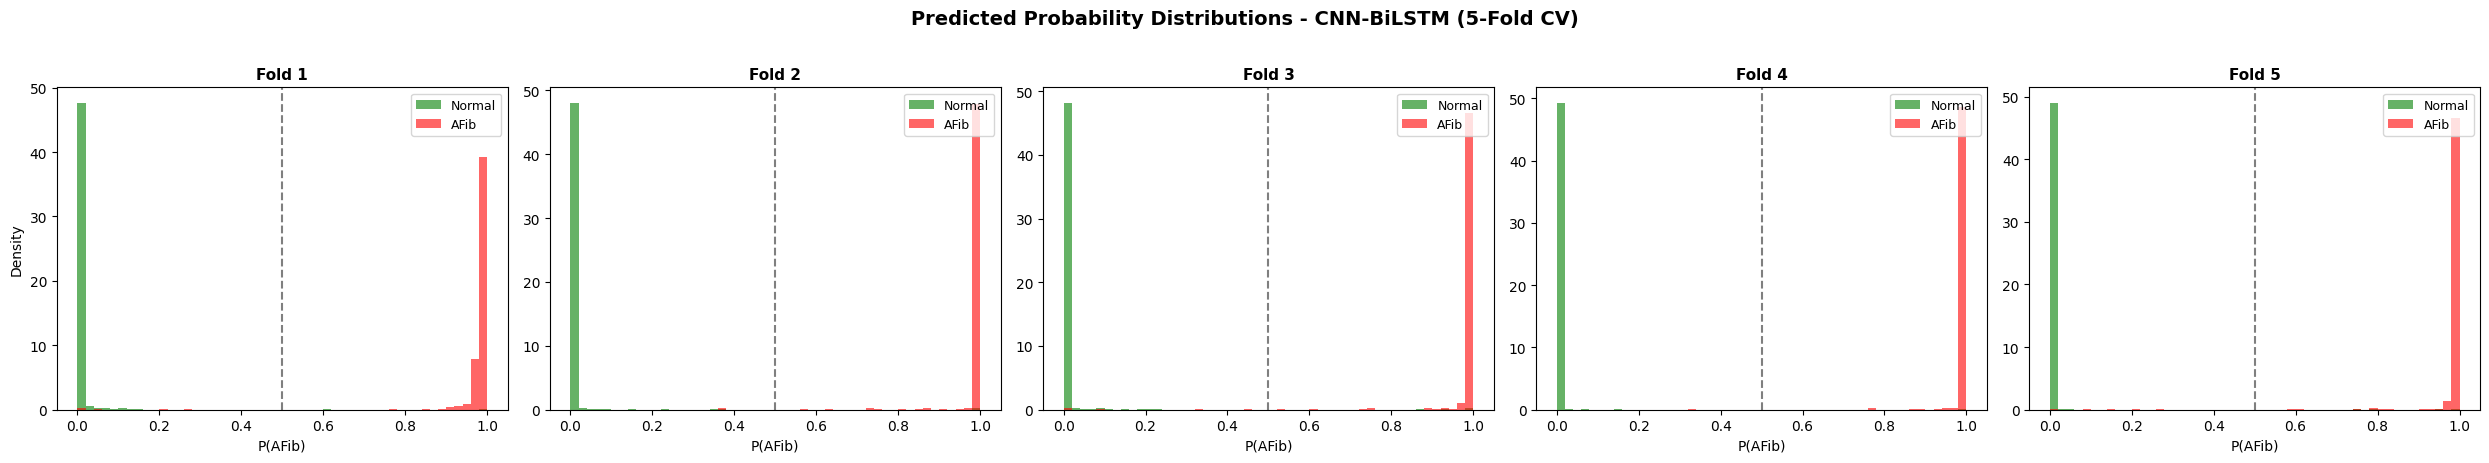

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4.5))
for i in range(len(folds)):
    ax = axes[i]
    mask_neg = all_fold_targets[i] == 0
    mask_pos = all_fold_targets[i] == 1
    ax.hist(all_fold_probs[i][mask_neg], bins=50, range=(0, 1), alpha=0.6, color='green', label='Normal', density=True)
    ax.hist(all_fold_probs[i][mask_pos], bins=50, range=(0, 1), alpha=0.6, color='red', label='AFib', density=True)
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f"Fold {i+1}", fontsize=11, fontweight='bold')
    ax.set_xlabel("P(AFib)")
    if i == 0: ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Predicted Probability Distributions - CNN-BiLSTM (5-Fold CV)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "cnn_bilstm_probability_distributions.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 17. Metrics Comparison Across Folds

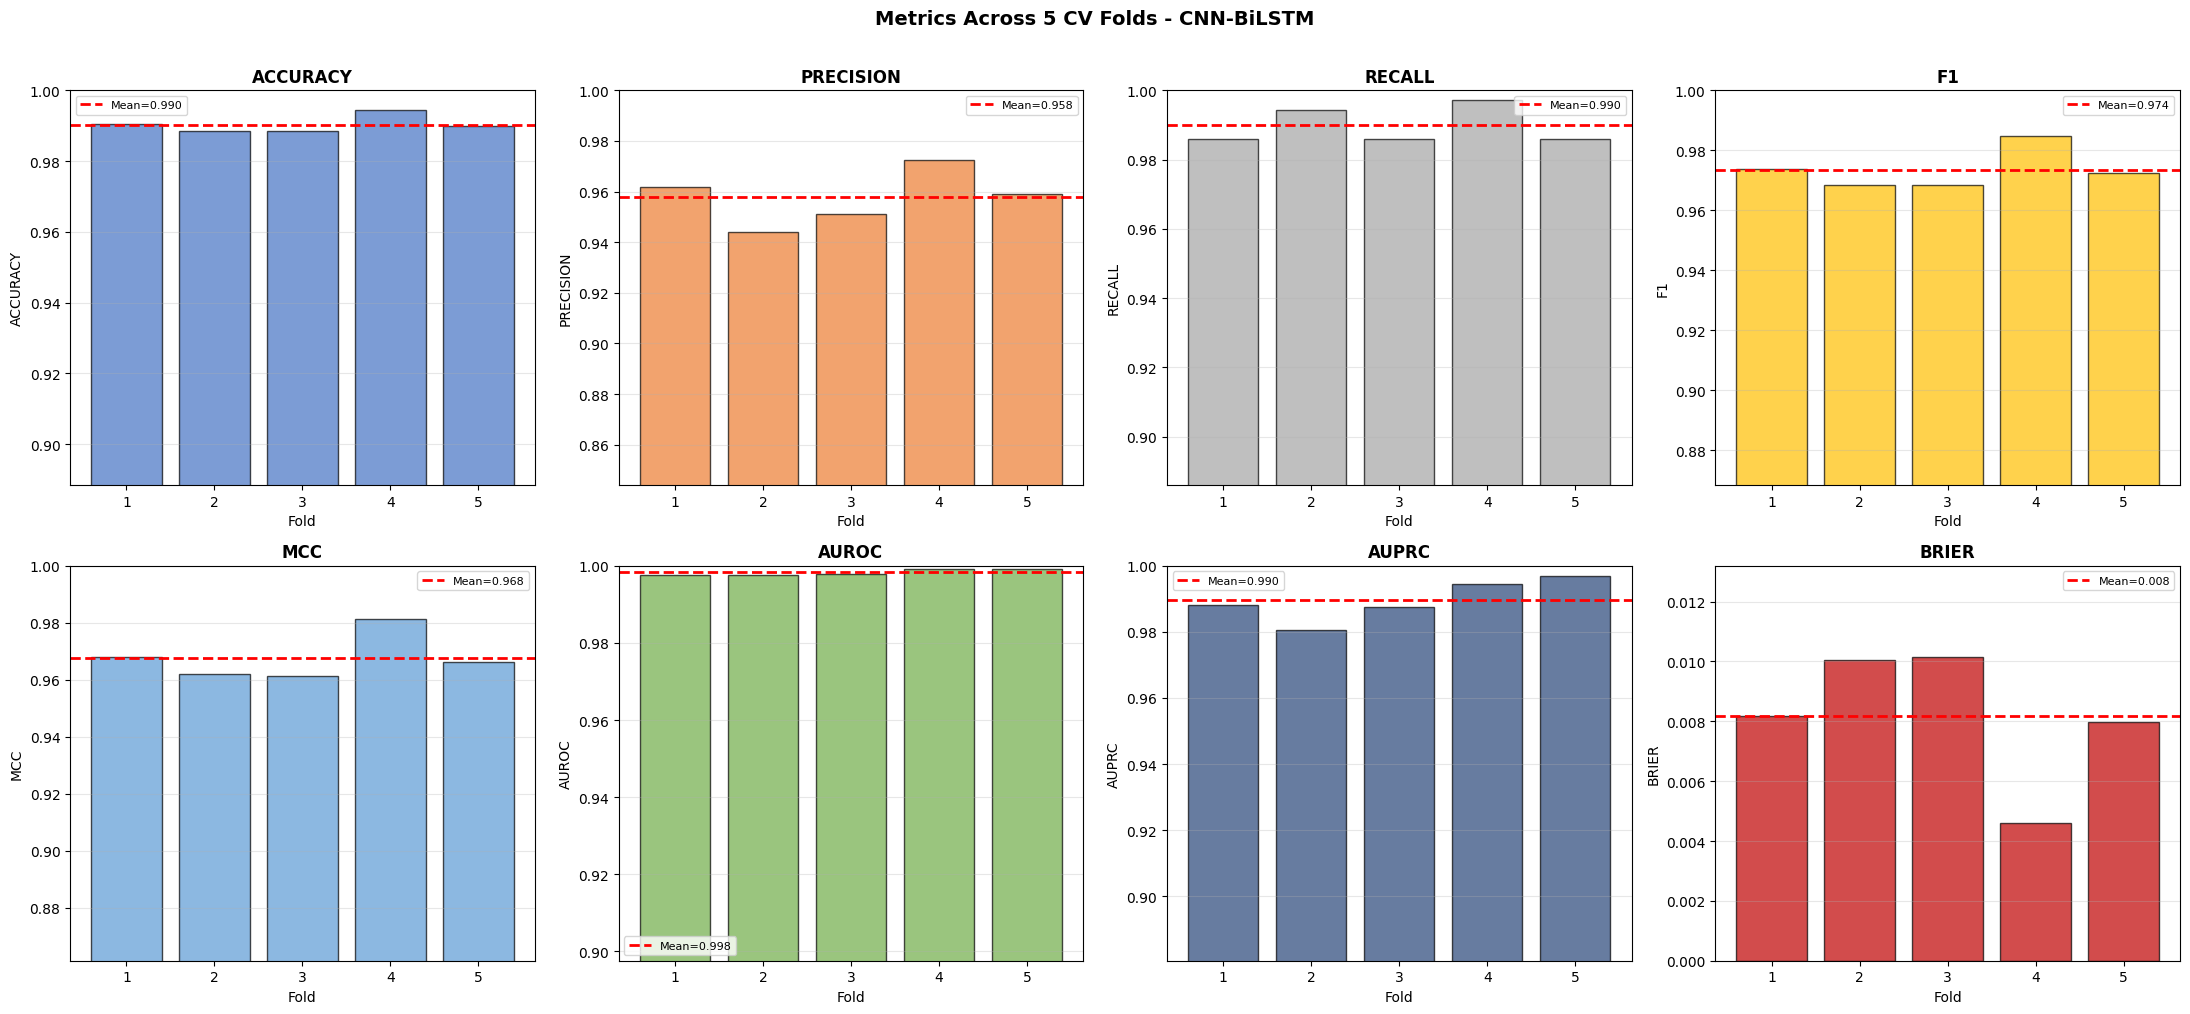

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
plot_metrics = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier"]
colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000', '#5B9BD5', '#70AD47', '#264478', '#C00000']
for idx, metric in enumerate(plot_metrics):
    row, col = idx // 4, idx % 4
    ax = axes[row][col]
    values = [m[metric] for m in all_fold_metrics]
    mean_val = np.mean(values)
    ax.bar(range(1, len(folds)+1), values, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.axhline(y=mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean={mean_val:.3f}')
    ax.set_xlabel("Fold"); ax.set_ylabel(metric.upper())
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, len(folds)+1))
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)
    if metric == "brier": ax.set_ylim([0, max(values) * 1.3])
    else: ax.set_ylim([max(0, min(values) - 0.1), 1.0])
plt.suptitle("Metrics Across 5 CV Folds - CNN-BiLSTM", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "cnn_bilstm_metrics_comparison.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 18. Training & Validation Loss Curves

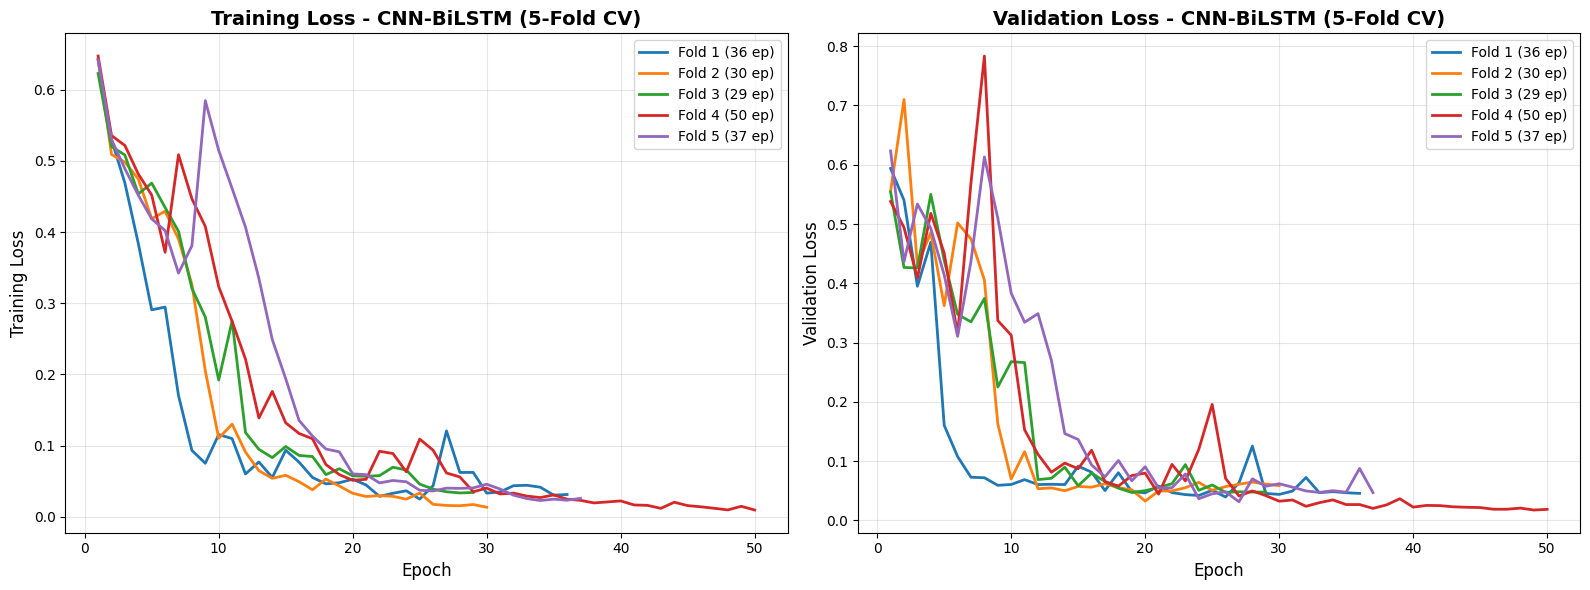

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for i, history in enumerate(all_fold_histories):
    epochs = range(1, len(history["train_loss"]) + 1)
    ax.plot(epochs, history["train_loss"], linewidth=2, label=f'Fold {i+1} ({len(history["train_loss"])} ep)')
ax.set_xlabel("Epoch", fontsize=12); ax.set_ylabel("Training Loss", fontsize=12)
ax.set_title("Training Loss - CNN-BiLSTM (5-Fold CV)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
for i, history in enumerate(all_fold_histories):
    epochs = range(1, len(history["val_loss"]) + 1)
    ax.plot(epochs, history["val_loss"], linewidth=2, label=f'Fold {i+1} ({len(history["val_loss"])} ep)')
ax.set_xlabel("Epoch", fontsize=12); ax.set_ylabel("Validation Loss", fontsize=12)
ax.set_title("Validation Loss - CNN-BiLSTM (5-Fold CV)", fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "cnn_bilstm_training_loss_curves.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 19. Comparison: CNN-BiLSTM vs KanResWideX

In [20]:
print("=" * 70)
print("COMPARISON: CNN-BiLSTM vs KanResWideX (both on Chapman-Shaoxing)")
print("=" * 70)
print()
print(f"{'Metric':<15} {'CNN-BiLSTM':<20} {'KanResWideX':<20}")
print("-" * 55)

kanres_results = {
    "accuracy": 0.9939, "precision": 0.9726, "recall": 0.9949,
    "f1": 0.9836, "mcc": 0.9800, "auroc": 0.9994, "auprc": 0.9968,
    "brier": 0.0048, "ece": 0.0048, "mce": 0.6711
}

for metric in ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier", "ece", "mce"]:
    bilstm_val = np.mean([m[metric] for m in all_fold_metrics])
    kanres_val = kanres_results[metric]
    better = "BiLSTM" if (bilstm_val > kanres_val and metric not in ["brier", "ece", "mce"]) or \
                         (bilstm_val < kanres_val and metric in ["brier", "ece", "mce"]) else "KanRes"
    print(f"{metric.upper():<15} {bilstm_val:<20.4f} {kanres_val:<20.4f} {'<-- ' + better}")

COMPARISON: CNN-BiLSTM vs KanResWideX (both on Chapman-Shaoxing)

Metric          CNN-BiLSTM           KanResWideX         
-------------------------------------------------------
ACCURACY        0.9903               0.9939               <-- KanRes
PRECISION       0.9577               0.9726               <-- KanRes
RECALL          0.9899               0.9949               <-- KanRes
F1              0.9735               0.9836               <-- KanRes
MCC             0.9678               0.9800               <-- KanRes
AUROC           0.9983               0.9994               <-- KanRes
AUPRC           0.9895               0.9968               <-- KanRes
BRIER           0.0082               0.0048               <-- KanRes
ECE             0.0072               0.0048               <-- KanRes
MCE             0.5204               0.6711               <-- BiLSTM


## 20. Final Summary

In [21]:
print("=" * 70)
print("FINAL 5-FOLD CV SUMMARY - CNN-BiLSTM (12-Lead, AFib vs Normal)")
print("=" * 70)
print()
summary_metrics = ["accuracy", "precision", "recall", "f1", "mcc", "auroc", "auprc", "brier", "ece", "mce"]
print(f"{'Metric':<20} {'Mean +/- Std':<25}")
print("-" * 45)
for m in summary_metrics:
    mean_v = np.mean([f[m] for f in all_fold_metrics])
    std_v = np.std([f[m] for f in all_fold_metrics])
    print(f"{m.upper():<20} {mean_v:.4f} +/- {std_v:.4f}")
print()
print(f"{'Confusion Matrix':<20} {'Mean +/- Std':<25}")
print("-" * 45)
for m in ["tn", "fp", "fn", "tp"]:
    mean_v = np.mean([f[m] for f in all_fold_metrics])
    std_v = np.std([f[m] for f in all_fold_metrics])
    print(f"{m.upper():<20} {mean_v:.0f} +/- {std_v:.0f}")
print()
print(f"Model: CNN-BiLSTM (3 CNN blocks + 2 BiLSTM layers)")
print(f"Input: All 12 leads at {config.fs} Hz")
print(f"Recording: Full {config.recording_seconds}s ({config.recording_samples} samples)")
print(f"Dataset: Chapman-Shaoxing (AFib + Normal Sinus Rhythm subset)")
print(f"Patients: {len(patient_data)} (AFib: {afib_patients}, Normal: {normal_patients})")
print(f"Total CV time: {total_cv_time/60:.1f} minutes")

FINAL 5-FOLD CV SUMMARY - CNN-BiLSTM (12-Lead, AFib vs Normal)

Metric               Mean +/- Std             
---------------------------------------------
ACCURACY             0.9903 +/- 0.0022
PRECISION            0.9577 +/- 0.0097
RECALL               0.9899 +/- 0.0049
F1                   0.9735 +/- 0.0060
MCC                  0.9678 +/- 0.0073
AUROC                0.9983 +/- 0.0008
AUPRC                0.9895 +/- 0.0058
BRIER                0.0082 +/- 0.0020
ECE                  0.0072 +/- 0.0020
MCE                  0.5204 +/- 0.1090

Confusion Matrix     Mean +/- Std             
---------------------------------------------
TN                   1606 +/- 4
FP                   16 +/- 4
FN                   4 +/- 2
TP                   352 +/- 2

Model: CNN-BiLSTM (3 CNN blocks + 2 BiLSTM layers)
Input: All 12 leads at 500 Hz
Recording: Full 10s (5000 samples)
Dataset: Chapman-Shaoxing (AFib + Normal Sinus Rhythm subset)
Patients: 9889 (AFib: 1780, Normal: 8109)
Total CV time: 8

## 21. Save Best Model

In [22]:
val_f1s = [m["f1"] for m in all_fold_metrics]
best_fold_idx = np.argmax(val_f1s)
print(f"Best fold: Fold {best_fold_idx+1} (Val F1={val_f1s[best_fold_idx]:.4f})")

save_path = os.path.join(config.model_save_dir, "best_cnn_bilstm_12lead.pth")
torch.save(all_fold_model_states[best_fold_idx], save_path)
print(f"Model saved to: {save_path}")

print(f"\nSaved PDF plots in: {config.pdf_dir}")
for f_name in sorted(os.listdir(config.pdf_dir)):
    if f_name.endswith('.pdf'):
        print(f"  {f_name}")

Best fold: Fold 4 (Val F1=0.9847)
Model saved to: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_cnn_bilstm_12lead.pth

Saved PDF plots in: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/plots_pdf_cnn_bilstm
  cnn_bilstm_calibration_plots.pdf
  cnn_bilstm_confusion_matrices.pdf
  cnn_bilstm_metrics_comparison.pdf
  cnn_bilstm_precision_recall_curves.pdf
  cnn_bilstm_probability_distributions.pdf
  cnn_bilstm_roc_curves.pdf
  cnn_bilstm_training_loss_curves.pdf
